#HW 3: Counting Inversions

- Please disable code autocomplete by uncheck "Show context-powered code completions" in Tools -> Settings -> Editor.

##Exhaustive Search for Counting Inversions
Refer to Section 3.2.4

In [7]:
# Exhaustive Search for Counting Inversions
def CountingInversionsExhaustiveSearch(array):
    count = 0
    for i in range(len(array) - 1):
        if array[i] > array[i + 1]:
            count += 1
    
    return count


In [8]:
# Quick test on function CountingInversionsExhaustiveSearch
TestArray = [[1, 2, 3, 4, 5, 6],
             [1, 3, 5, 2, 4, 6],
             [6, 5, 4, 3, 2, 1]]
for array in TestArray:
    print(CountingInversionsExhaustiveSearch(array))

0
1
5


##Divide-and-Conquer Approach for Counting Inversions
Refer to Sections 3.2.5 - 3.2.10

In [4]:
# Divide-and-conquer method
def CountingInversionsDivideAndConquer(array):
    arr_len = len(array)
    if arr_len <= 1:
        return array, 0
    
    mid = arr_len // 2
    left, inverted_left = CountingInversionsDivideAndConquer(array[:mid])
    right, inverted_right = CountingInversionsDivideAndConquer(array[mid:])

    merged, inverted_split = MergeAndCountSplitInv(left, right)
    
    return merged, inverted_left + inverted_right + inverted_split

def MergeAndCountSplitInv(leftArray, rightArray):
    merged = []
    i = j = 0
    inversions = 0

    while i < len(leftArray) and j < len(rightArray):
        if leftArray[i] <= rightArray[j]:
            merged.append(leftArray[i])
            i += 1
            continue
            
        merged.append(rightArray[j])
        inversions += len(leftArray) - i
        j += 1

    merged.extend(leftArray[i:])
    merged.extend(rightArray[j:])
    
    return merged, inversions

In [5]:
# Quick test on function CountingInversionsDivideAndConquer
TestArray = [[1, 2, 3, 4, 5, 6],
             [1, 3, 5, 2, 4, 6],
             [6, 5, 4, 3, 2, 1]]
for array in TestArray:
    _, result = CountingInversionsDivideAndConquer(array)
    print(result)

0
3
15


##Compare the performance of exhaustive search and divide-and-conquer methods

Error: results do not match
Array:  [15795   860  5390 11964 11284  6265 16850  4426 14423 11363 16023  8322
  1685   769  2433  5311  5051  6420 17568 19769  6396  8666 18942 18431
  2747   189 19118  3005  1899  1267 17912 11394  3556  3890  8838 14502
 10627  8792 10555 10253  8433 10233 11016  2612 15787 17159 12206  8226
 14541  3152  1585  3943 19457  1021 11653 10805 13417  7989  9692 12990
  6873  5675   161  4297   995 11534  7629  1016  8529 17262  9268 12185
  6331  8571  7208  5276 18446 16448 16216  8006  2568  2027  2695 15422
  5258  6736   391 13986 12666  5892  3561  6184 19483  8392 13067 15265
 19488  2454 11837 14039]
Exhaustive Search:  52
Divide and Conquer:  2423
Error: results do not match
Array:  [19115 10965  9762  5056 14948  8110 13773 17412   502  6910 12685   206
 17868 15934 17247 19174  8755 12383 18141 14820  7574  6374  1678 19626
  1059 16198  9914 19541 10817 10921  9789 16312 11252  2693 13931  3627
 16157 10173 18047 10230 15707 11494  1306  6776  

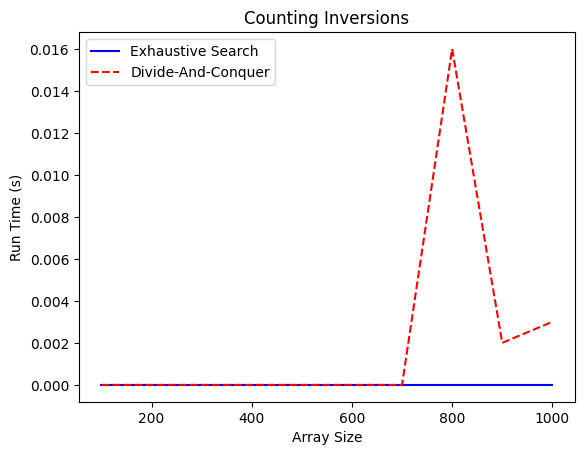

In [8]:
import numpy as np
import time
import matplotlib.pyplot as plt

maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArray(size):
    return np.random.randint(0, maxNumber, size)

averageRunTimesExhaustiveSearch = []
averageRunTimesDivideAndConquer = []

np.random.seed(42)

for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
    runTimesExhaustiveSearch = []
    runTimesDivideAndConquer = []

    for run in range(runsPerSize):
        array = GenerateRandomArray(arraySize)

        start = time.time()
        resultExhaustiveSearch = CountingInversionsExhaustiveSearch(array)
        end = time.time()
        runTimesExhaustiveSearch.append(end-start)

        start = time.time()
        _, resultDivideAndConquer = CountingInversionsDivideAndConquer(array)
        end = time.time()
        runTimesDivideAndConquer.append(end-start)

        if resultExhaustiveSearch != resultDivideAndConquer:
            print("Error: results do not match")
            print("Array: ", array)
            print("Exhaustive Search: ", resultExhaustiveSearch)
            print("Divide and Conquer: ", resultDivideAndConquer)
            break

    averageRunTimesExhaustiveSearch.append(np.mean(runTimesExhaustiveSearch))
    averageRunTimesDivideAndConquer.append(np.mean(runTimesDivideAndConquer))

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesExhaustiveSearch, 'b', label='Exhaustive Search')
plt.plot(x, averageRunTimesDivideAndConquer, 'r--', label='Divide-And-Conquer')
plt.title('Counting Inversions')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()
